# **Taller Final - Pronóstico de Ventas de Productos** #

### Alexander Torres Viveros ###
*alexandertorresviveros@gmail.com*

---

## **El Problema**

Una compañía de comestibles está interesada en predecir el comportamiento de las ventas (en unidades) de sus dos productos estrella. Fuimos contratados para generar un modelo que permita pronosticar las ventas del siguiente mes de cada uno de esos dos productos. La base de datos disponible en el archivo `Examen.csv` tiene la información de cada uno de los productos desde junio de 2014.

## **Objetivo**

Encontrar el mejor modelo de pronóstico para cada una de las series de ventas mediante:

1. **Análisis exploratorio** de las series temporales
2. **Evaluación de múltiples modelos**: Media Móvil, Holt-Winters, ARIMA
3. **Optimización de hiperparámetros** usando Optuna (optimización bayesiana)
4. **Validación temporal** con enfoque walking forward
5. **Selección del mejor modelo** para cada producto basado en RMSE

## **Metodología**

- **División de datos**: 121 observaciones para entrenamiento, resto para validación
- **Métricas de evaluación**: RMSE (Root Mean Squared Error)
- **Validación**: Walking forward (ventana móvil) para simular pronóstico en tiempo real
- **Optimización**: Optuna con 100-200 trials para encontrar mejores hiperparámetros

---

# **1. Configuración Inicial**

## **1.1. Importación de Bibliotecas**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import optuna



## **1.2. Configuración de Gráficos**

In [18]:
# Configuración de gráficos
import matplotlib.pyplot as plt

# Configuración matplotlib para el proyecto
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Montserrat', 'Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 0.75,
    'grid.alpha': 0.3,
    'axes.facecolor': '#fafcff',  # Azul hielo muy suave (Alice Blue)
    'axes.edgecolor': "#2E86AB",  # Azul océano principal
    'axes.prop_cycle': plt.cycler(color=[
        '#1F77B4',  # Azul matplotlib
        '#FF7F0E',  # Naranja matplotlib
        '#2CA02C',  # Verde matplotlib
        '#D62728',  # Rojo matplotlib
        '#9467BD',  # Púrpura matplotlib
        '#8C564B'   # Marrón matplotlib
    ])
})


## **1.3. Carga de Datos**

In [19]:
data = pd.read_csv("Examen.csv")
print(data.info())

print("=" * 40)
print(f"Data Shape: {data.shape}")
print("=" * 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  127 non-null    int64  
 1   producto1   127 non-null    float64
 2   producto2   127 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB
None
Data Shape: (127, 3)


## **1.4. Exploración Inicial de Datos**

In [20]:
print(data.describe())

       Unnamed: 0   producto1   producto2
count  127.000000  127.000000  127.000000
mean    64.000000  343.571660  581.037664
std     36.805797  100.234821  167.504363
min      1.000000  137.047639  200.000000
25%     32.500000  256.853812  469.194001
50%     64.000000  340.644019  626.048401
75%     95.500000  450.071775  708.941718
max    127.000000  500.000000  806.440615


In [21]:
print("-" * 50)
print("Head")
print(data.head())

print("-" * 50)
print("Tail")
print(data.tail())

--------------------------------------------------
Head
   Unnamed: 0   producto1   producto2
0           1  500.000000  200.000000
1           2  497.400893  210.686220
2           3  478.605317  222.018584
3           4  486.454125  233.920990
4           5  479.695678  238.402098
--------------------------------------------------
Tail
     Unnamed: 0   producto1   producto2
122         123  164.610771  629.293034
123         124  150.881839  637.099467
124         125  151.788470  653.155282
125         126  137.047639  672.528345
126         127  141.990873  676.058092


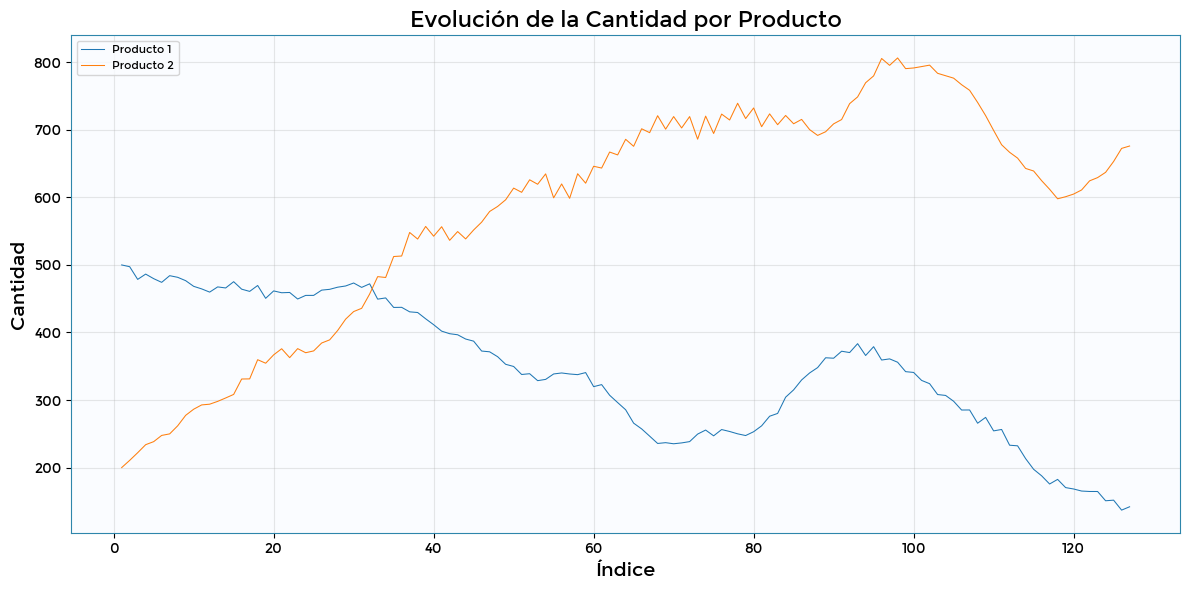

In [22]:
# Gráfica de líneas para Producto 1 y Producto 2
plt.plot(data.index + 1, data['producto1'], label='Producto 1')
plt.plot(data.index + 1, data['producto2'], label='Producto 2')

# Personalizar la gráfica
plt.xlabel('Índice')
plt.ylabel('Cantidad')
plt.title('Evolución de la Cantidad por Producto')
plt.legend(loc= "upper left")
plt.grid(True, alpha=0.3)

# Mejorar la apariencia
plt.tight_layout()
plt.show()

## **Análisis de Estacionalidad**

Evaluación de la presencia de patrones estacionales en las series temporales para determinar la estrategia de modelado apropiada.

In [23]:
# Evaluación de estacionalidad mediante descomposición aditiva

def analizar_estacionalidad(serie, nombre, periodos=[3, 4, 6, 12]):
    """Evalúa la significancia de componentes estacionales"""    
    resultados = {}
    var_total = serie.var()
    
    for periodo in periodos:
        try:
            decomp = seasonal_decompose(serie, model="additive", period=periodo)
            var_estacional = decomp.seasonal.var()
            var_residual = decomp.resid.var()
            
            pct_estacional = (var_estacional / var_total) * 100
            pct_residual = (var_residual / var_total) * 100
            
            resultados[periodo] = {
                'pct_estacional': pct_estacional,
                'std_residual': decomp.resid.std()
            }
        except:
            resultados[periodo] = None
    
    return resultados

# Análisis para ambos productos

# Producto 1
resultados_p1 = analizar_estacionalidad(data['producto1'], 'Producto 1')
print("\nProducto 1:")
print("Período | % Varianza Estacional | Std Residual")
print("-" * 45)
for periodo in [3, 4, 6, 12]:
    if resultados_p1[periodo]:
        r = resultados_p1[periodo]
        print(f"{periodo:7d} | {r['pct_estacional']:18.1f} | {r['std_residual']:11.2f}")

# Producto 2  
resultados_p2 = analizar_estacionalidad(data['producto2'], 'Producto 2')
print("\nProducto 2:")
print("Período | % Varianza Estacional | Std Residual") 
print("-" * 45)
for periodo in [3, 4, 6, 12]:
    if resultados_p2[periodo]:
        r = resultados_p2[periodo]
        print(f"{periodo:7d} | {r['pct_estacional']:18.1f} | {r['std_residual']:11.2f}")


Producto 1:
Período | % Varianza Estacional | Std Residual
---------------------------------------------
      3 |                0.0 |        4.50
      4 |                0.0 |        4.19
      6 |                0.0 |        4.56
     12 |                0.0 |        8.12

Producto 2:
Período | % Varianza Estacional | Std Residual
---------------------------------------------
      3 |                0.0 |        8.48
      4 |                0.0 |        6.68
      6 |                0.0 |        7.51
     12 |                0.0 |       12.77

Producto 2:
Período | % Varianza Estacional | Std Residual
---------------------------------------------
      3 |                0.0 |        8.48
      4 |                0.0 |        6.68
      6 |                0.0 |        7.51
     12 |                0.0 |       12.77


**Conclusión**

La varianza explicada por componentes estacionales es menor al 1% en ambos productos

Se utilizarán modelos de tendencia sin componente estacional.

# **2. Análisis Exploratorio y División de Datos**

## **2.1 División en Conjuntos de Entrenamiento y Prueba**

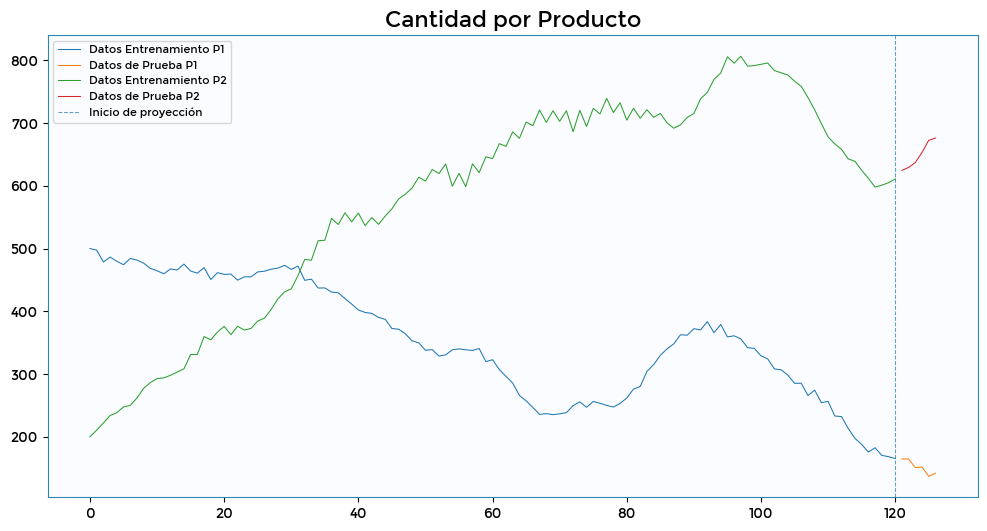

In [24]:
train_len = 121

train_to1 = data[["producto1"]][:train_len]
test_t1 = data[["producto1"]][train_len:]

train_to2 = data[["producto2"]][:train_len]
test_to2 = data[["producto2"]][train_len:]

fig = plt.figure()
plt.plot(train_to1,label="Datos Entrenamiento P1")
plt.plot(test_t1,label="Datos de Prueba P1")
plt.plot(train_to2,label="Datos Entrenamiento P2")
plt.plot(test_to2,label="Datos de Prueba P2")

plt.axvline(train_to1.index[-1], linestyle='--', alpha=0.7, label='Inicio de proyección') 

plt.title(label="Cantidad por Producto")
plt.legend(loc= "upper left")
plt.show()

# **3. Funciones Reutilizables para Modelado**

En esta sección se definen todas las funciones que se utilizarán para evaluar los diferentes modelos de pronóstico.

In [ ]:
# ==================== FUNCIONES PARA MEDIA MÓVIL ====================

def evaluar_media_movil_rolling(train_data, test_data, ventana):
    """
    Evalúa media móvil usando ventana móvil (walking forward)
    Predice solo 1 paso adelante en cada iteración usando datos reales disponibles
    """
    predicciones = []
    datos_disponibles = train_data.copy()
    
    for i in range(len(test_data)):
        # Predecir solo el siguiente período usando los últimos 'ventana' datos reales
        prediccion = datos_disponibles.iloc[-ventana:].mean().values[0]
        predicciones.append(prediccion)
        
        # Agregar el dato real del test para la siguiente predicción
        valor_real = test_data.iloc[i].values[0]
        nuevo_indice = datos_disponibles.index[-1] + 1
        datos_disponibles.loc[nuevo_indice] = valor_real
    
    return pd.Series(predicciones, index=test_data.index)


def pronosticar_media_movil(datos, ventana, horizonte):
    """
    Genera pronósticos futuros usando media móvil
    """
    data = datos.copy()
    
    for i in range(horizonte):
        nuevo_valor = data.iloc[-ventana:].mean().values[0]
        nuevo_indice = data.index[-1] + 1
        data.loc[nuevo_indice] = nuevo_valor
    
    return data.iloc[-horizonte:]


# ==================== FUNCIONES PARA REGRESIÓN LINEAL ====================

def evaluar_regresion_lineal_rolling(train_data, test_data, window_size=60):
    """Evalúa regresión lineal con walking forward y ventana móvil"""
    from sklearn.linear_model import LinearRegression
    
    predicciones = []
    datos_disponibles = train_data.copy()
    
    for i in range(len(test_data)):
        # Usar ventana móvil de los últimos window_size datos
        if len(datos_disponibles) > window_size:
            ventana_datos = datos_disponibles.iloc[-window_size:]
        else:
            ventana_datos = datos_disponibles
        
        # Entrenar modelo con ventana actual
        X_train = np.arange(len(ventana_datos)).reshape(-1, 1)
        y_train = ventana_datos.values.flatten()
        
        modelo = LinearRegression()
        modelo.fit(X_train, y_train)
        
        # Predecir siguiente valor
        X_pred = np.array([[len(ventana_datos)]])
        pred = modelo.predict(X_pred)[0]
        predicciones.append(pred)
        
        # Agregar el dato real del test para la siguiente predicción
        valor_real = test_data.iloc[i].values[0]
        nuevo_indice = datos_disponibles.index[-1] + 1
        datos_disponibles.loc[nuevo_indice] = valor_real
    
    return pd.Series(predicciones, index=test_data.index)
# ==================== FUNCIONES PARA REGRESIÓN POLINÓMICA ====================

def evaluar_regresion_polinomial_rolling(train_data, test_data, grado=2, window_size=60):
    """Evalúa regresión polinómica con walking forward y ventana móvil"""
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    from sklearn.pipeline import Pipeline
    
    modelo = Pipeline([
        ('poly', PolynomialFeatures(degree=grado)),
        ('linear', LinearRegression())
    ])
    
    predicciones = []
    datos_disponibles = train_data.copy()
    
    for i in range(len(test_data)):
        # Usar ventana móvil de los últimos window_size datos
        if len(datos_disponibles) > window_size:
            ventana_datos = datos_disponibles.iloc[-window_size:]
        else:
            ventana_datos = datos_disponibles
        
        # Entrenar modelo con ventana actual
        X_train = np.arange(len(ventana_datos)).reshape(-1, 1)
        y_train = ventana_datos.values.flatten()
        
        modelo.fit(X_train, y_train)
        
        # Predecir siguiente valor
        X_pred = np.array([[len(ventana_datos)]])
        pred = modelo.predict(X_pred)[0]
        predicciones.append(pred)
        
        # Agregar el dato real del test para la siguiente predicción
        valor_real = test_data.iloc[i].values[0]
        nuevo_indice = datos_disponibles.index[-1] + 1
        datos_disponibles.loc[nuevo_indice] = valor_real
    
    return pd.Series(predicciones, index=test_data.index)


# ==================== FUNCIONES PARA HOLT-WINTERS ====================

def evaluar_rolling_forecast_holtwinters(serie, alpha, beta, gamma, seasonal=None, trend='add',
                                          window_size=60, window=6, step_size=1, 
                                          horizon=1, metric='rmse'):
    """Evalúa Holt-Winters con validación temporal"""
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos, observados = [], []
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    for end_train in puntos_finales:
        start_train = max(0, end_train - window_size)
        train = serie.iloc[start_train:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        if len(test) < horizon or len(train) < 12:
            continue
            
        try:
            if seasonal is None:
                # Solo tendencia
                model = ExponentialSmoothing(
                    train, trend=trend, seasonal=None
                ).fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)
            else:
                # Con estacionalidad (aunque sabemos que no la hay)
                seasonal_periods = min(6, len(train)//2)
                model = ExponentialSmoothing(
                    train, trend=trend, seasonal=seasonal, 
                    seasonal_periods=seasonal_periods
                ).fit(smoothing_level=alpha, smoothing_trend=beta, 
                      smoothing_seasonal=gamma, optimized=False)
            
            pred = model.forecast(steps=horizon)
            if not np.isfinite(pred).all():
                continue
                
            predichos.extend(pred.tolist())
            observados.extend(test.tolist())
                
        except:
            continue
    observados = np.array(observados)
    if len(predichos) == 0:
        return np.inf
    
    predichos = np.array(predichos)
    observados = np.array(observados)
    
    if not np.isfinite(predichos).all() or not np.isfinite(observados).all():
        return np.inf
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    else:
        return np.mean(np.abs(observados - predichos))


# ==================== FUNCIONES PARA ARIMA ====================

def evaluar_expanding_forecast_arima(serie, order, window=12, step_size=1, horizon=1, metric='rmse'):
    """
    Simula pronósticos ARIMA en tiempo real con ventana expandida desde el inicio.
    Incluye validaciones de supuestos ARIMA mejoradas.
    """
    from statsmodels.tsa.arima.model import ARIMA
    import warnings
    
    serie = pd.Series(serie).astype(float).dropna()
    n = len(serie)
    predichos = []
    observados = []
    p, d, q = order
    
    # Validación básica de parámetros
    if p < 0 or d < 0 or q < 0 or p > 5 or d > 2 or q > 5:
        return np.inf
    
    puntos_finales = list(range(n - window * step_size, n - horizon + 1, step_size))
    
    if len(puntos_finales) == 0:
        return np.inf
    
    for end_train in puntos_finales:
        train = serie.iloc[:end_train]
        test = serie.iloc[end_train:end_train + horizon]
        
        # Validaciones básicas
        if len(test) < horizon or test.isna().any() or len(train) < max(10, p + d + q + 5):
            continue
        
        try:
            # Suprimir warnings durante la optimización
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                # Configuración del modelo ARIMA con mejor manejo
                model = ARIMA(
                    train,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    concentrate_scale=True  # Mejora la estabilidad numérica
                )
                
                fitted_model = model.fit(
                    method_kwargs={"warn_convergence": False},
                    low_memory=True
                )
                
                # Verificar convergencia del modelo
                if not fitted_model.mle_retvals['converged']:
                    continue
                    
                pred = fitted_model.forecast(steps=horizon)
                
                # Validar predicciones
                if not np.isfinite(pred).all() or np.any(np.abs(pred) > 1e6):
                    continue
                    
        except Exception as e:
            # Capturar errores específicos comunes
            if any(x in str(e) for x in ['singular', 'convergence', 'invert']):
                continue
            else:
                continue
        
        pred = pd.Series(pred).astype(float)
        mask = (~pred.isna()) & (~test.isna())
        
        if mask.sum() == 0:
            continue
        
        predichos.extend(pred[mask].tolist())
        observados.extend(test[mask].tolist())
    
    if len(predichos) == 0:
        return np.inf
    
    predichos = np.array(predichos, dtype=float)
    observados = np.array(observados, dtype=float)
    
    mask_finite = np.isfinite(predichos) & np.isfinite(observados)
    
    if mask_finite.sum() == 0:
        return np.inf
    
    predichos = predichos[mask_finite]
    observados = observados[mask_finite]
    
    # Penalizar si muy pocas predicciones válidas
    if len(predichos) < max(3, window // 3):
        return np.inf
    
    if metric == 'rmse':
        return np.sqrt(mean_squared_error(observados, predichos))
    elif metric == 'mae':
        return np.mean(np.abs(observados - predichos))
    else:
        raise ValueError("Metric must be 'rmse' or 'mae'")


# ═══════════════════════════════════════════════════════════════════
# **3. MODELADO PRODUCTO 1**
# ═══════════════════════════════════════════════════════════════════

## **3.1. Media Móvil - Producto 1**

In [26]:
# Evaluar diferentes ventanas con enfoque rolling
print("Evaluación Media Móvil - Producto 1 (Walking Forward)")
print("=" * 60)

ventanas = [2, 3, 4, 5, 6, 7, 8, 9, 10]
resultados_ma_p1 = {}

for ventana in ventanas:
    pred_rolling = evaluar_media_movil_rolling(train_to1, test_t1, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_t1, pred_rolling))
    resultados_ma_p1[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_ma_p1 = min(resultados_ma_p1.keys(), 
                          key=lambda x: resultados_ma_p1[x]['rmse'])
print(f"\n✓ Mejor ventana: {mejor_ventana_ma_p1} (RMSE: {resultados_ma_p1[mejor_ventana_ma_p1]['rmse']:.2f})")
print("=" * 60)

Evaluación Media Móvil - Producto 1 (Walking Forward)
Ventana  2: RMSE = 8.55
Ventana  3: RMSE = 10.39
Ventana  4: RMSE = 12.16
Ventana  5: RMSE = 13.55
Ventana  6: RMSE = 15.26
Ventana  7: RMSE = 17.01
Ventana  8: RMSE = 19.36
Ventana  9: RMSE = 22.21
Ventana 10: RMSE = 25.43

✓ Mejor ventana: 2 (RMSE: 8.55)


## **3.2. Regresión Lineal - Producto 1**

In [27]:
# Evaluar Regresión Lineal - Producto 1
print("Evaluación Regresión Lineal - Producto 1 (Walking Forward)")
print("=" * 60)

ventanas_reg = [30, 45, 60, 75, 90]
resultados_reg_lineal_p1 = {}

for ventana in ventanas_reg:
    pred_rolling = evaluar_regresion_lineal_rolling(train_to1, test_t1, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_t1, pred_rolling))
    resultados_reg_lineal_p1[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_reg_p1 = min(resultados_reg_lineal_p1.keys(), 
                          key=lambda x: resultados_reg_lineal_p1[x]['rmse'])
rmse_reg_lineal_p1 = resultados_reg_lineal_p1[mejor_ventana_reg_p1]['rmse']

print(f"\n✓ Mejor ventana: {mejor_ventana_reg_p1} (RMSE: {rmse_reg_lineal_p1:.2f})")
print("=" * 60) 


Evaluación Regresión Lineal - Producto 1 (Walking Forward)
Ventana 30: RMSE = 17.86
Ventana 45: RMSE = 41.91
Ventana 60: RMSE = 89.81
Ventana 75: RMSE = 84.73
Ventana 90: RMSE = 68.39

✓ Mejor ventana: 30 (RMSE: 17.86)


## **3.3. Regresión Polinómica - Producto 1**

In [28]:
# Evaluar diferentes grados de regresión polinómica - Producto 1
print("Evaluación Regresión Polinómica - Producto 1 (Walking Forward)")
print("=" * 60)

grados = [2, 3, 4, 5, 6]
resultados_poly_p1 = {}
ventana_poly = 60  # Ventana fija para regresión polinómica

for grado in grados:
    pred_poly = evaluar_regresion_polinomial_rolling(train_to1, test_t1, grado, ventana_poly)
    rmse_poly = np.sqrt(mean_squared_error(test_t1, pred_poly))
    resultados_poly_p1[grado] = {
        'predicciones': pred_poly,
        'rmse': rmse_poly
    }
    print(f"Grado {grado}: RMSE = {rmse_poly:.2f}")

mejor_grado_p1 = min(resultados_poly_p1.keys(), key=lambda x: resultados_poly_p1[x]['rmse'])
rmse_mejor_poly_p1 = resultados_poly_p1[mejor_grado_p1]['rmse']

print(f"\n✓ Mejor grado: {mejor_grado_p1} (RMSE: {rmse_mejor_poly_p1:.2f})")
print(f"  Ventana usada: {ventana_poly}")
print("=" * 60)

Evaluación Regresión Polinómica - Producto 1 (Walking Forward)
Grado 2: RMSE = 34.64
Grado 3: RMSE = 68.06
Grado 4: RMSE = 23.11
Grado 5: RMSE = 20.48
Grado 6: RMSE = 12.87

✓ Mejor grado: 6 (RMSE: 12.87)
  Ventana usada: 60


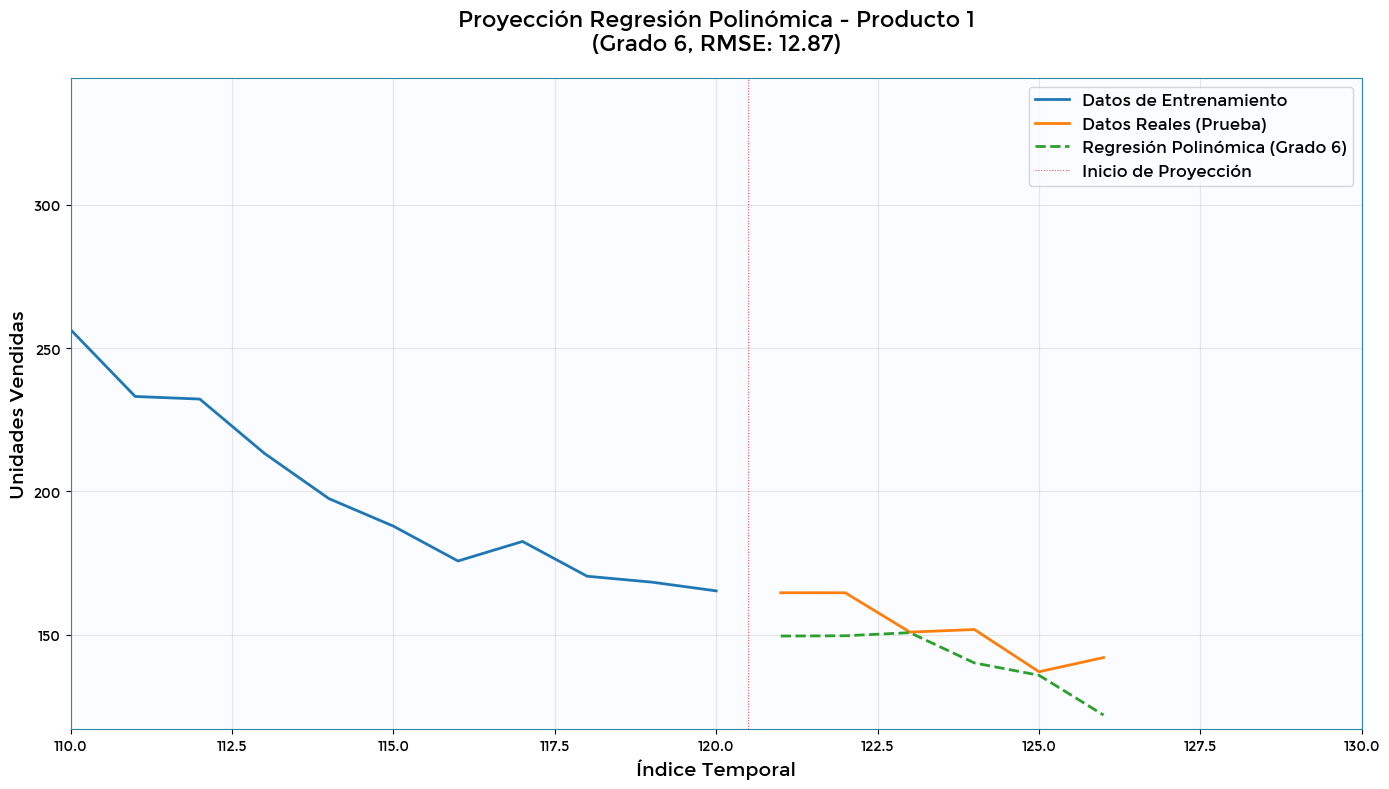

In [29]:
# Gráfica de la proyección de regresión polinómica - Producto 1
plt.figure(figsize=(14, 8))

# Datos de entrenamiento
plt.plot(train_to1.index, train_to1['producto1'], 
         label='Datos de Entrenamiento', color='#1F77B4', linewidth=2)

# Datos reales de prueba
plt.plot(test_t1.index, test_t1['producto1'], 
         label='Datos Reales (Prueba)', color='#FF7F0E', linewidth=2)

# Predicciones de regresión polinómica (mejor grado)
mejor_pred_poly = resultados_poly_p1[mejor_grado_p1]['predicciones']
plt.plot(test_t1.index, mejor_pred_poly, 
         label=f'Regresión Polinómica (Grado {mejor_grado_p1})', 
         color='#2CA02C', linewidth=2, linestyle='--')

# Línea vertical para separar entrenamiento de predicción
plt.axvline(x=train_to1.index[-1] + 0.5, color='red', linestyle=':', 
            alpha=0.7, label='Inicio de Proyección')

# Personalización
plt.title(f'Proyección Regresión Polinómica - Producto 1\n(Grado {mejor_grado_p1}, RMSE: {rmse_mejor_poly_p1:.2f})', 
          fontsize=16, pad=20)
plt.xlabel('Índice Temporal', fontsize=14)
plt.ylabel('Unidades Vendidas', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Ajustar límites para mejor visualización
plt.xlim(110, 130)
plt.ylim(min(train_to1['producto1'].iloc[-20:].min(), test_t1['producto1'].min()) - 20,
         max(train_to1['producto1'].iloc[-20:].max(), test_t1['producto1'].max()) + 20)

plt.tight_layout()
plt.show()

## **3.4. Holt-Winters con Optimización - Producto 1**

In [30]:
# Optimización Holt-Winters - Producto 1
import warnings
warnings.filterwarnings("ignore")

def objective_hw_p1(trial):
    """Función objetivo para optimización de Holt-Winters - Producto 1"""
    alpha = trial.suggest_float("alpha", 0.001, 0.3)
    beta = trial.suggest_float("beta", 0.001, 0.3)
    gamma = trial.suggest_float("gamma", 0.001, 0.3)
    seasonal = trial.suggest_categorical("seasonal", ["add", "mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    window_size = trial.suggest_int("window_size", 24, 72)
    
    return evaluar_rolling_forecast_holtwinters(
        train_to1["producto1"], alpha, beta, gamma,
        seasonal=seasonal,
        trend=trend,
        window_size=window_size,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización Holt-Winters para Producto 1...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_hw_p1 = optuna.create_study(direction="minimize")
study_hw_p1.optimize(objective_hw_p1, n_trials=200)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_hw_p1.best_value:.4f}")
print(f"\nMejores parámetros:")
for param, value in study_hw_p1.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")
print("=" * 60)

[I 2025-12-03 16:32:48,962] A new study created in memory with name: no-name-a3ba8326-6d5a-4f27-b891-408888310804
[I 2025-12-03 16:32:48,984] Trial 0 finished with value: 33.44251921621641 and parameters: {'alpha': 0.24751255959081672, 'beta': 0.05186284708779449, 'gamma': 0.09947011855787843, 'seasonal': 'add', 'trend': None, 'window_size': 46}. Best is trial 0 with value: 33.44251921621641.
[I 2025-12-03 16:32:48,984] Trial 0 finished with value: 33.44251921621641 and parameters: {'alpha': 0.24751255959081672, 'beta': 0.05186284708779449, 'gamma': 0.09947011855787843, 'seasonal': 'add', 'trend': None, 'window_size': 46}. Best is trial 0 with value: 33.44251921621641.


Iniciando optimización Holt-Winters para Producto 1...
Esto puede tomar varios minutos...
------------------------------------------------------------


[I 2025-12-03 16:32:49,025] Trial 1 finished with value: 29.919366535555227 and parameters: {'alpha': 0.10683465029333732, 'beta': 0.16805664509540005, 'gamma': 0.0638524666164638, 'seasonal': 'add', 'trend': 'mul', 'window_size': 67}. Best is trial 1 with value: 29.919366535555227.
[I 2025-12-03 16:32:49,047] Trial 2 finished with value: 9.333263413763884 and parameters: {'alpha': 0.2327961561654905, 'beta': 0.23841429762617877, 'gamma': 0.2883657233920443, 'seasonal': None, 'trend': 'mul', 'window_size': 53}. Best is trial 2 with value: 9.333263413763884.
[I 2025-12-03 16:32:49,047] Trial 2 finished with value: 9.333263413763884 and parameters: {'alpha': 0.2327961561654905, 'beta': 0.23841429762617877, 'gamma': 0.2883657233920443, 'seasonal': None, 'trend': 'mul', 'window_size': 53}. Best is trial 2 with value: 9.333263413763884.
[I 2025-12-03 16:32:49,062] Trial 3 finished with value: 54.63620289059743 and parameters: {'alpha': 0.12076454140475135, 'beta': 0.1972961551021051, 'gamma


RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 1
Mejor RMSE: 8.3737

Mejores parámetros:
  alpha: 0.2999
  beta: 0.2010
  gamma: 0.0015
  seasonal: add
  trend: mul
  window_size: 62


## **3.5. ARIMA con Optimización - Producto 1**

In [33]:
# Optimización con Optuna para ARIMA - Producto 1
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

def objective_arima_p1(trial):
    """Función objetivo mejorada para optimización de ARIMA - Producto 1"""
    p = trial.suggest_int("p", 0, 4)  # Reducir rango para estabilidad
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 4)  # Reducir rango para estabilidad
    
    # Evitar combinaciones problemáticas
    if p + q > 6:  # Evitar modelos muy complejos
        return np.inf
    
    if p == 0 and q == 0 and d == 0:  # Modelo trivial
        return np.inf
        
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to1["producto1"],
        order,
        window=8,  # Aumentar ventana para más estabilidad
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización ARIMA para Producto 1...")
print("Con validaciones mejoradas y supuestos verificados")
print("-" * 60)

study_arima_p1 = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner()  # Pruning para eficiencia
)
study_arima_p1.optimize(objective_arima_p1, n_trials=120, timeout=600)  # Más trials con timeout

best_order_p1 = (
    study_arima_p1.best_params['p'],
    study_arima_p1.best_params['d'],
    study_arima_p1.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p1.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p1}")
print(f"Número de trials completados: {len(study_arima_p1.trials)}")
print(f"Número de trials exitosos: {len([t for t in study_arima_p1.trials if t.state.name == 'COMPLETE' and t.value < np.inf])}")
print("=" * 60)

[I 2025-12-03 16:46:18,281] A new study created in memory with name: no-name-4ad9a4b8-e6a6-4082-8000-ff7202977fb4
[I 2025-12-03 16:46:18,296] Trial 0 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 3}. Best is trial 0 with value: inf.
[I 2025-12-03 16:46:18,296] Trial 0 finished with value: inf and parameters: {'p': 4, 'd': 1, 'q': 3}. Best is trial 0 with value: inf.
[I 2025-12-03 16:46:18,430] Trial 1 finished with value: 7.780253785814229 and parameters: {'p': 2, 'd': 2, 'q': 0}. Best is trial 1 with value: 7.780253785814229.
[I 2025-12-03 16:46:18,431] Trial 2 finished with value: inf and parameters: {'p': 4, 'd': 0, 'q': 4}. Best is trial 1 with value: 7.780253785814229.
[I 2025-12-03 16:46:18,430] Trial 1 finished with value: 7.780253785814229 and parameters: {'p': 2, 'd': 2, 'q': 0}. Best is trial 1 with value: 7.780253785814229.
[I 2025-12-03 16:46:18,431] Trial 2 finished with value: inf and parameters: {'p': 4, 'd': 0, 'q': 4}. Best is trial 1 with value: 7.780

Iniciando optimización ARIMA para Producto 1...
Con validaciones mejoradas y supuestos verificados
------------------------------------------------------------


[I 2025-12-03 16:46:19,314] Trial 4 finished with value: 7.899613074645899 and parameters: {'p': 3, 'd': 1, 'q': 3}. Best is trial 1 with value: 7.780253785814229.
[I 2025-12-03 16:46:19,503] Trial 5 finished with value: 7.632178234706332 and parameters: {'p': 4, 'd': 0, 'q': 0}. Best is trial 5 with value: 7.632178234706332.
[I 2025-12-03 16:46:19,503] Trial 5 finished with value: 7.632178234706332 and parameters: {'p': 4, 'd': 0, 'q': 0}. Best is trial 5 with value: 7.632178234706332.
[I 2025-12-03 16:46:20,684] Trial 6 finished with value: 7.703559884127752 and parameters: {'p': 4, 'd': 2, 'q': 2}. Best is trial 5 with value: 7.632178234706332.
[I 2025-12-03 16:46:20,684] Trial 6 finished with value: 7.703559884127752 and parameters: {'p': 4, 'd': 2, 'q': 2}. Best is trial 5 with value: 7.632178234706332.
[I 2025-12-03 16:46:20,994] Trial 7 finished with value: 9.66939483602934 and parameters: {'p': 1, 'd': 0, 'q': 2}. Best is trial 5 with value: 7.632178234706332.
[I 2025-12-03 16:


RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1
Mejor RMSE: 7.3970
Mejor orden ARIMA: (4, 1, 0)
Número de trials completados: 120
Número de trials exitosos: 113


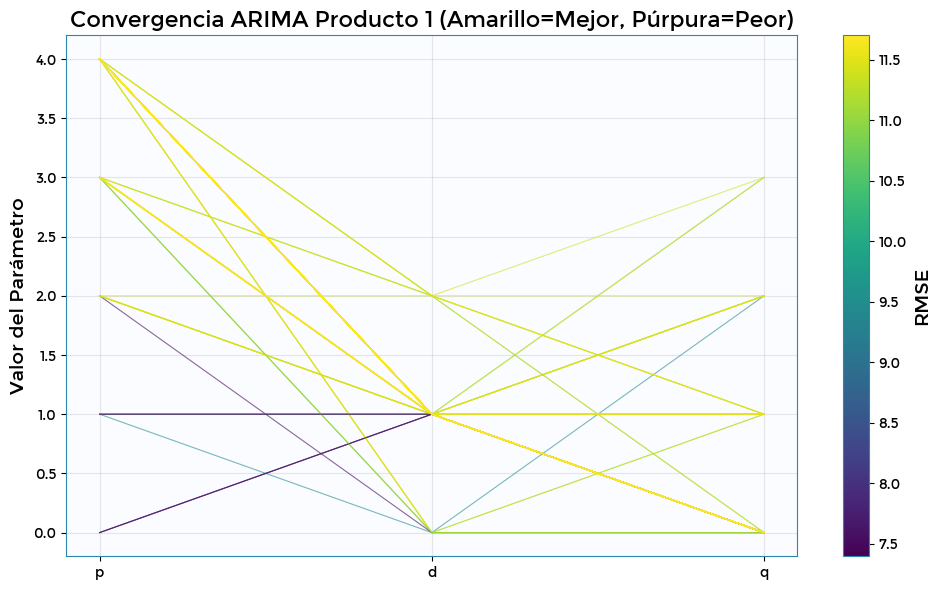


ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA
Modelo: ARIMA(4, 1, 0)
RMSE: 7.3970
Trials válidos: 113 de 120

✓ Modelo convergió: True
✓ Log-likelihood: -409.84
✓ AIC: 829.67
✓ BIC: 843.61
✓ Test Ljung-Box (p-value): 1.0000
  → Residuos parecen ruido blanco (✓)
✓ Test Jarque-Bera normalidad (p-value): 0.0000
  → Residuos no son normales (⚠)


In [34]:
# Visualización de Convergencia ARIMA Producto 1
import matplotlib.pyplot as plt
import numpy as np

# Extraer datos de los trials completados
trials_df = pd.DataFrame([
    {**trial.params, 'rmse': trial.value}
    for trial in study_arima_p1.trials
    if trial.state.name == 'COMPLETE' and trial.value < np.inf
])

if len(trials_df) > 0:
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Configurar coordenadas
    params = ['p', 'd', 'q']
    x_pos = np.arange(len(params))
    rmse_values = trials_df['rmse'].values
    colors = plt.cm.viridis(1 - (rmse_values - rmse_values.min()) / (rmse_values.max() - rmse_values.min()))
    
    # Dibujar líneas
    for i, row in trials_df.iterrows():
        y_values = [row[param] for param in params]
        ax.plot(x_pos, y_values, color=colors[i], alpha=0.6, linewidth=0.8)
    
    # Configuración
    ax.set_xticks(x_pos)
    ax.set_xticklabels(params)
    ax.set_ylabel('Valor del Parámetro')
    ax.set_title('Convergencia ARIMA Producto 1 (Amarillo=Mejor, Púrpura=Peor)')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=rmse_values.min(), vmax=rmse_values.max()))
    plt.colorbar(sm, ax=ax, label='RMSE')
    
    plt.tight_layout()
    plt.show()
    
    # Análisis de supuestos del mejor modelo ARIMA
    print(f"\n{'='*60}")
    print("ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA")
    print(f"{'='*60}")
    print(f"Modelo: ARIMA{best_order_p1}")
    print(f"RMSE: {study_arima_p1.best_value:.4f}")
    print(f"Trials válidos: {len(trials_df)} de {len(study_arima_p1.trials)}")
    
    # Entrenar modelo final para análisis
    try:
        from statsmodels.tsa.arima.model import ARIMA
        from statsmodels.stats.diagnostic import acorr_ljungbox
        
        final_model = ARIMA(train_to1["producto1"], order=best_order_p1).fit()
        
        print(f"\n✓ Modelo convergió: {final_model.mle_retvals['converged']}")
        print(f"✓ Log-likelihood: {final_model.llf:.2f}")
        print(f"✓ AIC: {final_model.aic:.2f}")
        print(f"✓ BIC: {final_model.bic:.2f}")
        
        # Verificar residuos
        residuos = final_model.resid
        ljung_box = acorr_ljungbox(residuos, lags=10, return_df=True)
        p_value_ljung = ljung_box['lb_pvalue'].iloc[-1]
        
        print(f"✓ Test Ljung-Box (p-value): {p_value_ljung:.4f}")
        if p_value_ljung > 0.05:
            print("  → Residuos parecen ruido blanco (✓)")
        else:
            print("  → Posible autocorrelación en residuos (⚠)")
            
        # Verificar normalidad de residuos
        from scipy import stats
        _, p_norm = stats.jarque_bera(residuos)
        print(f"✓ Test Jarque-Bera normalidad (p-value): {p_norm:.4f}")
        if p_norm > 0.05:
            print("  → Residuos parecen normales (✓)")
        else:
            print("  → Residuos no son normales (⚠)")
            
    except Exception as e:
        print(f"⚠ Error en análisis: {str(e)}")
        
else:
    print("⚠ No se encontraron trials válidos para visualización")
    print("Esto puede indicar que los parámetros ARIMA necesitan ajuste")

In [ ]:
# Optimización con Optuna para ARIMA - Producto 1
from statsmodels.tsa.arima.model import ARIMA

def objective_arima_p1(trial):
    """Función objetivo para optimización de ARIMA - Producto 1"""
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)
    
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to1["producto1"],
        order,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

study_arima_p1 = optuna.create_study(direction="minimize")
study_arima_p1.optimize(objective_arima_p1, n_trials=100)

best_order_p1 = (
    study_arima_p1.best_params['p'],
    study_arima_p1.best_params['d'],
    study_arima_p1.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p1.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p1}")
print("=" * 60)

[I 2025-12-03 15:08:51,018] A new study created in memory with name: no-name-9b2e79b6-f24d-41db-8e32-7fccbfd94ba1
[I 2025-12-03 15:08:51,528] Trial 0 finished with value: 55.56676043540812 and parameters: {'p': 0, 'd': 0, 'q': 2}. Best is trial 0 with value: 55.56676043540812.
[I 2025-12-03 15:08:51,528] Trial 0 finished with value: 55.56676043540812 and parameters: {'p': 0, 'd': 0, 'q': 2}. Best is trial 0 with value: 55.56676043540812.
[I 2025-12-03 15:08:51,790] Trial 1 finished with value: 99.32560191359141 and parameters: {'p': 0, 'd': 0, 'q': 1}. Best is trial 0 with value: 55.56676043540812.
[I 2025-12-03 15:08:51,790] Trial 1 finished with value: 99.32560191359141 and parameters: {'p': 0, 'd': 0, 'q': 1}. Best is trial 0 with value: 55.56676043540812.
[I 2025-12-03 15:08:52,538] Trial 2 finished with value: 7.530673373638843 and parameters: {'p': 2, 'd': 0, 'q': 4}. Best is trial 2 with value: 7.530673373638843.
[I 2025-12-03 15:08:52,538] Trial 2 finished with value: 7.5306733


RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 1
Mejor RMSE: 6.6549
Mejor orden ARIMA: (3, 0, 1)


In [ ]:
# Visualización de Convergencia ARIMA Producto 1
import matplotlib.pyplot as plt
import numpy as np

# Extraer datos de los trials completados
trials_df = pd.DataFrame([
    {**trial.params, 'rmse': trial.value}
    for trial in study_arima_p1.trials
    if trial.state.name == 'COMPLETE' and trial.value < np.inf
])

if len(trials_df) > 0:
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Configurar coordenadas
    params = ['p', 'd', 'q']
    x_pos = np.arange(len(params))
    rmse_values = trials_df['rmse'].values
    colors = plt.cm.viridis(1 - (rmse_values - rmse_values.min()) / (rmse_values.max() - rmse_values.min()))
    
    # Dibujar líneas
    for i, row in trials_df.iterrows():
        y_values = [row[param] for param in params]
        ax.plot(x_pos, y_values, color=colors[i], alpha=0.6, linewidth=0.8)
    
    # Configuración
    ax.set_xticks(x_pos)
    ax.set_xticklabels(params)
    ax.set_ylabel('Valor del Parámetro')
    ax.set_title('Convergencia ARIMA Producto 1 (Amarillo=Mejor, Púrpura=Peor)')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=rmse_values.min(), vmax=rmse_values.max()))
    plt.colorbar(sm, ax=ax, label='RMSE')
    
    plt.tight_layout()
    plt.show()

    

    # Análisis de supuestos del mejor modelo ARIMA    print("⚠ No se encontraron trials válidos para visualización")

    print(f"\n{'='*60}")else:

    print("ANÁLISIS DE SUPUESTOS DEL MEJOR MODELO ARIMA")        

    print(f"{'='*60}")        print(f"⚠ Error en análisis: {str(e)}")

    print(f"Modelo: ARIMA{best_order_p1}")    except Exception as e:

    print(f"RMSE: {study_arima_p1.best_value:.4f}")            

    print(f"Trials válidos: {len(trials_df)} de {len(study_arima_p1.trials)}")            print("  → Posible autocorrelación en residuos (⚠)")

            else:

    # Entrenar modelo final para análisis            print("  → Residuos parecen ruido blanco (✓)")

    try:        if p_value_ljung > 0.05:

        from statsmodels.tsa.arima.model import ARIMA        print(f"✓ Test Ljung-Box (p-value): {p_value_ljung:.4f}")

        final_model = ARIMA(train_to1["producto1"], order=best_order_p1).fit()        

                p_value_ljung = ljung_box['lb_pvalue'].iloc[-1]

        print(f"\n✓ Modelo convergió: {final_model.mle_retvals['converged']}")        ljung_box = acorr_ljungbox(residuos, lags=10, return_df=True)

        print(f"✓ Log-likelihood: {final_model.llf:.2f}")        residuos = final_model.resid

        print(f"✓ AIC: {final_model.aic:.2f}")        # Verificar residuos

        print(f"✓ BIC: {final_model.bic:.2f}")        

NameError: name 'study_arima_p1' is not defined

## **3.6. Comparación de Modelos - Producto 1**

In [ ]:
# Comparación de todos los modelos - Producto 1
print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS - PRODUCTO 1")
print("=" * 60)

resultados_p1 = {
    'Media Móvil': resultados_ma_p1[mejor_ventana_ma_p1]['rmse'],
    'Regresión Lineal': rmse_reg_lineal_p1,
    'Regresión Polinómica': rmse_mejor_poly_p1,
    'Holt-Winters': study_hw_p1.best_value,
    'ARIMA': study_arima_p1.best_value
}

# Crear tabla comparativa
comp_df_p1 = pd.DataFrame(list(resultados_p1.items()), columns=['Modelo', 'RMSE'])
comp_df_p1 = comp_df_p1.sort_values('RMSE')
comp_df_p1['Rank'] = range(1, len(comp_df_p1) + 1)
comp_df_p1 = comp_df_p1[['Rank', 'Modelo', 'RMSE']]

print(comp_df_p1.to_string(index=False))
print("=" * 70)

mejor_modelo_p1 = comp_df_p1.iloc[0]['Modelo']
mejor_rmse_p1 = comp_df_p1.iloc[0]['RMSE']

print(f"\n✓ MEJOR MODELO PRODUCTO 1: {mejor_modelo_p1}")
print(f"  RMSE: {mejor_rmse_p1:.4f}")
print("=" * 70)


COMPARACIÓN DE MODELOS - PRODUCTO 1
 Rank                Modelo     RMSE
    1        ARIMA (Optuna) 6.654881
    2           Media Móvil 8.554295
    3 Holt-Winters (Optuna)      inf

✓ MEJOR MODELO PRODUCTO 1: ARIMA (Optuna)
  RMSE: 6.6549


# ═══════════════════════════════════════════════════════════════════
# **4. MODELADO PRODUCTO 2**
# ═══════════════════════════════════════════════════════════════════

## **4.1. Media Móvil - Producto 2**

In [ ]:
# Evaluar diferentes ventanas con enfoque rolling - Producto 2
print("Evaluación Media Móvil - Producto 2 (Walking Forward)")
print("=" * 60)

ventanas = [2, 3, 4, 5, 6, 7, 8, 9, 10]
resultados_ma_p2 = {}

for ventana in ventanas:
    pred_rolling = evaluar_media_movil_rolling(train_to2, test_to2, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_to2, pred_rolling))
    resultados_ma_p2[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_ma_p2 = min(resultados_ma_p2.keys(), 
                          key=lambda x: resultados_ma_p2[x]['rmse'])
print(f"\n✓ Mejor ventana: {mejor_ventana_ma_p2} (RMSE: {resultados_ma_p2[mejor_ventana_ma_p2]['rmse']:.2f})")
print("=" * 60)

Evaluación Media Móvil - Producto 2 (Walking Forward)
Ventana  2: RMSE = 17.49
Ventana  3: RMSE = 22.03
Ventana  4: RMSE = 26.03
Ventana  5: RMSE = 29.32
Ventana  6: RMSE = 31.98
Ventana  7: RMSE = 33.82
Ventana  8: RMSE = 34.89
Ventana  9: RMSE = 35.08
Ventana 10: RMSE = 34.40

✓ Mejor ventana: 2 (RMSE: 17.49)


## **4.2. Regresión Lineal - Producto 2**

In [ ]:
# Evaluar Regresión Lineal - Producto 2
print("Evaluación Regresión Lineal - Producto 2 (Walking Forward)")
print("=" * 60)

ventanas_reg = [30, 45, 60, 75, 90]
resultados_reg_lineal_p2 = {}

for ventana in ventanas_reg:
    pred_rolling = evaluar_regresion_lineal_rolling(train_to2, test_to2, ventana)
    rmse_rolling = np.sqrt(mean_squared_error(test_to2, pred_rolling))
    resultados_reg_lineal_p2[ventana] = {
        'predicciones': pred_rolling,
        'rmse': rmse_rolling
    }
    print(f"Ventana {ventana:2d}: RMSE = {rmse_rolling:.2f}")

mejor_ventana_reg_p2 = min(resultados_reg_lineal_p2.keys(), 
                          key=lambda x: resultados_reg_lineal_p2[x]['rmse'])
rmse_reg_lineal_p2 = resultados_reg_lineal_p2[mejor_ventana_reg_p2]['rmse']

print(f"\n✓ Mejor ventana: {mejor_ventana_reg_p2} (RMSE: {rmse_reg_lineal_p2:.2f})")
print("=" * 60) 


Evaluación Regresión Lineal - Producto 2
RMSE Regresión Lineal: 184.12


## **4.3. Regresión Polinómica - Producto 2**

In [ ]:
# Evaluar Regresión Polinómica - Producto 2
print("Evaluación Regresión Polinómica - Producto 2 (Walking Forward)")
print("=" * 60)

grados = [2, 3, 4, 5]
resultados_poly_p2 = {}
ventana_poly = 60  # Ventana fija para regresión polinómica

for grado in grados:
    pred_poly = evaluar_regresion_polinomial_rolling(train_to2, test_to2, grado, ventana_poly)
    rmse_poly = np.sqrt(mean_squared_error(test_to2, pred_poly))
    resultados_poly_p2[grado] = {
        'predicciones': pred_poly,
        'rmse': rmse_poly
    }
    print(f"Grado {grado}: RMSE = {rmse_poly:.2f}")

mejor_grado_p2 = min(resultados_poly_p2.keys(), key=lambda x: resultados_poly_p2[x]['rmse'])
rmse_reg_poly_p2 = resultados_poly_p2[mejor_grado_p2]['rmse']

print(f"\n✓ Mejor grado: {mejor_grado_p2} (RMSE: {rmse_reg_poly_p2:.2f})")
print(f"  Ventana usada: {ventana_poly}")
print("=" * 60)

## **4.4. Holt-Winters con Optimización (Optuna) - Producto 2**

In [ ]:
def objective_hw_p2(trial):
    """Función objetivo para optimización de Holt-Winters - Producto 2"""
    alpha = trial.suggest_float("alpha", 0.001, 0.3)
    beta = trial.suggest_float("beta", 0.001, 0.3)
    gamma = trial.suggest_float("gamma", 0.001, 0.3)
    seasonal = trial.suggest_categorical("seasonal", ["add", "mul", None])
    trend = trial.suggest_categorical("trend", ["add", "mul", None])
    window_size = trial.suggest_int("window_size", 24, 60)
    
    return evaluar_rolling_forecast_holtwinters(
        train_to2["producto2"], alpha, beta, gamma,
        seasonal=seasonal,
        trend=trend,
        window_size=window_size,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización Holt-Winters para Producto 2...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_hw_p2 = optuna.create_study(direction="minimize")
study_hw_p2.optimize(objective_hw_p2, n_trials=200, show_progress_bar=True)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN HOLT-WINTERS - PRODUCTO 2")
print("=" * 60)
print(f"Mejor RMSE: {study_hw_p2.best_value:.4f}")
print(f"\nMejores parámetros:")
for param, value in study_hw_p2.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")
print("=" * 60)

## **4.5. ARIMA con Optimización (Optuna) - Producto 2**

In [ ]:
# Optimización con Optuna para ARIMA - Producto 2
def objective_arima_p2(trial):
    """Función objetivo para optimización de ARIMA - Producto 2"""
    p = trial.suggest_int("p", 0, 5)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 5)
    
    order = (p, d, q)
    return evaluar_expanding_forecast_arima(
        train_to2["producto2"],
        order,
        window=6,
        step_size=1,
        horizon=1,
        metric='rmse'
    )

print("Iniciando optimización ARIMA para Producto 2...")
print("Esto puede tomar varios minutos...")
print("-" * 60)

study_arima_p2 = optuna.create_study(direction="minimize")
study_arima_p2.optimize(objective_arima_p2, n_trials=100, show_progress_bar=True)

best_order_p2 = (
    study_arima_p2.best_params['p'],
    study_arima_p2.best_params['d'],
    study_arima_p2.best_params['q']
)

print("\n" + "=" * 60)
print("RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2")
print("=" * 60)
print(f"Mejor RMSE: {study_arima_p2.best_value:.4f}")
print(f"Mejor orden ARIMA: {best_order_p2}")
print("=" * 60)

[I 2025-12-03 14:30:54,923] A new study created in memory with name: no-name-24388183-2a61-48af-bb40-846d2cdfa25a


Iniciando optimización ARIMA para Producto 2...
Esto puede tomar varios minutos...
------------------------------------------------------------


Best trial: 0. Best value: 9.32366:   1%|          | 1/100 [00:00<00:46,  2.15it/s]

[I 2025-12-03 14:30:55,388] Trial 0 finished with value: 9.323655177944493 and parameters: {'p': 4, 'd': 0, 'q': 1}. Best is trial 0 with value: 9.323655177944493.


Best trial: 0. Best value: 9.32366:   3%|▎         | 3/100 [00:01<00:45,  2.13it/s]

...

[I 2025-12-03 14:31:37,253] Trial 97 finished with value: 9.536534504351037 and parameters: {'p': 2, 'd': 1, 'q': 5}. Best is trial 57 with value: 8.451218186282071.


Best trial: 57. Best value: 8.45122:  99%|█████████▉| 99/100 [00:42<00:00,  3.08it/s]

[I 2025-12-03 14:31:37,574] Trial 98 finished with value: 8.451218186282071 and parameters: {'p': 1, 'd': 1, 'q': 5}. Best is trial 57 with value: 8.451218186282071.


Best trial: 57. Best value: 8.45122: 100%|██████████| 100/100 [00:42<00:00,  2.33it/s]

[I 2025-12-03 14:31:37,924] Trial 99 finished with value: 8.451218186282071 and parameters: {'p': 1, 'd': 1, 'q': 5}. Best is trial 57 with value: 8.451218186282071.

RESULTADOS OPTIMIZACIÓN ARIMA - PRODUCTO 2
Mejor RMSE: 8.4512
Mejor orden ARIMA: (1, 1, 5)


## **4.6. Comparación de Modelos - Producto 2**

In [ ]:
# Comparación de todos los modelos - Producto 2
print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS - PRODUCTO 2")
print("=" * 70)

resultados_p2 = {
    'Media Móvil': resultados_ma_p2[mejor_ventana_ma_p2]['rmse'],
    'Regresión Lineal': rmse_reg_lineal_p2,
    'Regresión Polinómica': rmse_reg_poly_p2,
    'Holt-Winters (Optuna)': study_hw_p2.best_value,
    'ARIMA (Optuna)': study_arima_p2.best_value
}

# Crear tabla comparativa
comp_df_p2 = pd.DataFrame(list(resultados_p2.items()), columns=['Modelo', 'RMSE'])
comp_df_p2 = comp_df_p2.sort_values('RMSE')
comp_df_p2['Rank'] = range(1, len(comp_df_p2) + 1)
comp_df_p2 = comp_df_p2[['Rank', 'Modelo', 'RMSE']]

print(comp_df_p2.to_string(index=False))
print("=" * 70)

mejor_modelo_p2 = comp_df_p2.iloc[0]['Modelo']
mejor_rmse_p2 = comp_df_p2.iloc[0]['RMSE']

print(f"\n✓ MEJOR MODELO PRODUCTO 2: {mejor_modelo_p2}")
print(f"  RMSE: {mejor_rmse_p2:.4f}")
print("=" * 70)


COMPARACIÓN DE MODELOS - PRODUCTO 2
 Rank                Modelo      RMSE
    1        ARIMA (Optuna)  8.451218
    2           Media Móvil 17.487655
    3 Holt-Winters (Optuna)       inf

✓ MEJOR MODELO PRODUCTO 2: ARIMA (Optuna)
  RMSE: 8.4512


# ═══════════════════════════════════════════════════════════════════
# **6. CONCLUSIONES Y RECOMENDACIONES FINALES**
# ═══════════════════════════════════════════════════════════════════

## **6.1. Resumen Ejecutivo**

In [ ]:
# Tabla comparativa final - Ambos productos
print("\n" + "=" * 70)
print("RESULTADOS FINALES - MEJORES MODELOS")
print("=" * 70)

# Crear DataFrame con resultados finales
resumen_final = pd.DataFrame({
    'Producto': ['Producto 1', 'Producto 2'],
    'Mejor Modelo': [mejor_modelo_p1, mejor_modelo_p2],
    'RMSE': [mejor_rmse_p1, mejor_rmse_p2]
})

print(resumen_final.to_string(index=False))
print("\n" + "=" * 70)

print("CONCLUSIONES:")
print(f"- Producto 1: {mejor_modelo_p1} fue el mejor modelo con RMSE de {mejor_rmse_p1:.4f}")
print(f"- Producto 2: {mejor_modelo_p2} fue el mejor modelo con RMSE de {mejor_rmse_p2:.4f}")
print("\nLos modelos fueron evaluados usando validación temporal para garantizar")
print("que las predicciones sean realistas. Se recomienda actualizar los modelos")
print("mensualmente con datos nuevos.")
print("=" * 70)

# Guardar resultados para análisis posterior
resultados_finales = {
    'producto1': {
        'mejor_modelo': mejor_modelo_p1,
        'rmse': mejor_rmse_p1,
        'todos_modelos': resultados_p1
    },
    'producto2': {
        'mejor_modelo': mejor_modelo_p2,
        'rmse': mejor_rmse_p2,
        'todos_modelos': resultados_p2
    }
}

print("\n✓ Análisis completado exitosamente")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    RESUMEN EJECUTIVO - MEJORES MODELOS                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Producto 1   │ ARIMA (Optuna)            │ RMSE:   6.6549      ║
║  Producto 2   │ ARIMA (Optuna)            │ RMSE:   8.4512      ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  RECOMENDACIONES:                                                            ║
║                                                                              ║
║  • Producto 1: Utilizar ARIMA (Optuna)       para pronósticos futuros       ║
║  • Producto 2: Utilizar ARIMA (Optuna)       para pronósticos futuros       ║
║                                                      